In [1]:
%load_ext autoreload
%autoreload 2
%autosave 30

Autosaving every 30 seconds


# Plot Scores
In this notebook we will investigate the scores of the models across different leadtimes

In [2]:
import json

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

import wandb

In [3]:
api = wandb.Api()

# Get runs with a specific tag
runs = api.runs(
    "feik/genpp",  # Replace with your entity/project
    filters={"tags": {"$all": ["final"], "$nin": ["deprecated"]}},
)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/feik/.netrc.


In [5]:
def parse_wandb_runs_to_polars(runs):
    """
    Parse WandB runs into a Polars DataFrame.
    Handles nested metrics with optional method keys (ECC, GCA, etc.)
    """
    rows = []

    for run in runs:
        run_id = run.id
        try:
            val_metrics = run.summary._json_dict["val"]
        except KeyError:
            print(f"Run {run_id} has no 'val' metrics, skipping.")
            continue
        json_config = json.loads(run.json_config)
        model_name = json_config["name"]["value"]
        # Check if metrics have method level (ECC, GCA) or not
        if any(key in val_metrics for key in ["ECC", "GCA"]):
            # Has method level (like EMOS, DRN)
            for method, method_metrics in val_metrics.items():
                if not isinstance(method_metrics, dict):
                    continue  # Skip non-dict values
                for metric_name, time_values in method_metrics.items():
                    if not isinstance(time_values, dict):
                        continue  # Skip non-dict values
                    for time_horizon, value in time_values.items():
                        # Convert time_horizon string (e.g., "24h") to hours integer
                        hours = int(time_horizon.rstrip("h"))
                        rows.append(
                            {
                                "run_id": run_id,
                                "model_name": model_name,
                                "method": method,
                                "pred_method": None,
                                "metric_name": metric_name,
                                "timedelta_hours": hours,
                                "value": value,
                            }
                        )
        else:  # No method level, metrics are directly under "val"
            # Determine loss function for method column, if available
            if json_config.get("model", False) and json_config["model"]["value"].get(
                "loss_fn", False
            ):
                loss_fn = json_config["model"]["value"]["loss_fn"]["_target_"].split(".")[-1]
            else:
                loss_fn = None
            # Determine if direct or indirect predictions
            tags = run.tags
            if "direct" in tags:
                pred_method = "direct"
            elif "indirect" in tags:
                pred_method = "indirect"
            else:
                pred_method = None

            for metric_name, time_values in val_metrics.items():
                if not isinstance(time_values, dict):
                    continue  # Skip non-dict values (like _wandb metadata)
                for time_horizon, value in time_values.items():
                    # Convert time_horizon string (e.g., "24h") to hours integer
                    hours = int(time_horizon.rstrip("h"))
                    rows.append(
                        {
                            "run_id": run_id,
                            "model_name": model_name,
                            "method": loss_fn,
                            "pred_method": pred_method,
                            "metric_name": metric_name,
                            "timedelta_hours": hours,
                            "value": value,
                        }
                    )
    # Create Polars DataFrame with explicit Duration type
    df = (
        pl.DataFrame(rows, infer_schema_length=1000)
        .with_columns(
            pl.col("timedelta_hours").mul(3600_000_000).cast(pl.Duration("us")).alias("timedelta"),
            # Rename model_name from CHEN to LNGM for better readability
            pl.col("model_name")
            .replace({"CHEN": "LNGM", "raw_ensemble": "RAW"})
            .alias("model_name"),
            # Rename loss fn to their short names for better readability
            pl.col("method")
            .replace(
                {
                    "EnergyScore": "ES",
                    "PatchwiseEnergyScore": "PES",
                    "MultiScaleEnergyScore": "MSES",
                    "MultiScalePatchwiseEnergyScore": "MSPES",
                }
            )
            .alias("method"),
        )
        .drop("timedelta_hours")
    )

    return df


df = parse_wandb_runs_to_polars(runs)
df

Run m5y9kwlh has no 'val' metrics, skipping.


run_id,model_name,method,pred_method,metric_name,value,timedelta
str,str,str,str,str,f64,duration[μs]
"""5mq2600w""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.714713,5d
"""5mq2600w""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.415069,1d
"""5mq2600w""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.473665,2d
"""5mq2600w""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.541893,3d
"""5mq2600w""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.631232,4d
…,…,…,…,…,…,…
"""yfigjk3e""","""LNGM""","""MSPES""","""direct""","""EnergyScore_combined""",51.029194,5d
"""yfigjk3e""","""LNGM""","""MSPES""","""direct""","""EnergyScore_combined""",27.417324,1d
"""yfigjk3e""","""LNGM""","""MSPES""","""direct""","""EnergyScore_combined""",31.898214,2d


In [6]:
# Prepare data for plotting using polars
df_plot = df.with_columns(
    [
        # Create combined model+method label
        pl.when(pl.col("method").is_not_null() & pl.col("pred_method").is_null())
        .then(pl.col("model_name") + " (" + pl.col("method") + ")")
        .when(pl.col("method").is_not_null() & pl.col("pred_method").is_not_null())
        .then(pl.col("model_name") + " (" + pl.col("method") + ", " + pl.col("pred_method") + ")")
        .when(pl.col("method").is_null() & pl.col("pred_method").is_not_null())
        .then(pl.col("model_name") + " (" + pl.col("pred_method") + ")")
        .otherwise(pl.col("model_name"))
        .alias("model_method"),
        # Convert timedelta to days for better readability
        (pl.col("timedelta").dt.total_days()).alias("days"),
        # Split metric_name into score and variable
        pl.col("metric_name").str.split("_").list.first().alias("score"),
        pl.col("metric_name").str.split("_").list.slice(1).list.join("_").alias("variable"),
    ]
).sort(["score", "variable", "model_method", "days"])

df_plot

run_id,model_name,method,pred_method,metric_name,value,timedelta,model_method,days,score,variable
str,str,str,str,str,f64,duration[μs],str,i64,str,str
"""co74yk64""","""EMOS""","""ECC""",null,"""CRPS_10m_windspeed""",0.377246,1d,"""EMOS (ECC)""",1,"""CRPS""","""10m_windspeed"""
"""co74yk64""","""EMOS""","""ECC""",null,"""CRPS_10m_windspeed""",0.443782,2d,"""EMOS (ECC)""",2,"""CRPS""","""10m_windspeed"""
"""co74yk64""","""EMOS""","""ECC""",null,"""CRPS_10m_windspeed""",0.518519,3d,"""EMOS (ECC)""",3,"""CRPS""","""10m_windspeed"""
"""co74yk64""","""EMOS""","""ECC""",null,"""CRPS_10m_windspeed""",0.613562,4d,"""EMOS (ECC)""",4,"""CRPS""","""10m_windspeed"""
"""co74yk64""","""EMOS""","""ECC""",null,"""CRPS_10m_windspeed""",0.698266,5d,"""EMOS (ECC)""",5,"""CRPS""","""10m_windspeed"""
…,…,…,…,…,…,…,…,…,…,…
"""5mq2600w""","""RAW""",null,null,"""VariogramScore_combined""",378034.40625,1d,"""RAW""",1,"""VariogramScore""","""combined"""
"""5mq2600w""","""RAW""",null,null,"""VariogramScore_combined""",439132.09375,2d,"""RAW""",2,"""VariogramScore""","""combined"""
"""5mq2600w""","""RAW""",null,null,"""VariogramScore_combined""",503419.78125,3d,"""RAW""",3,"""VariogramScore""","""combined"""


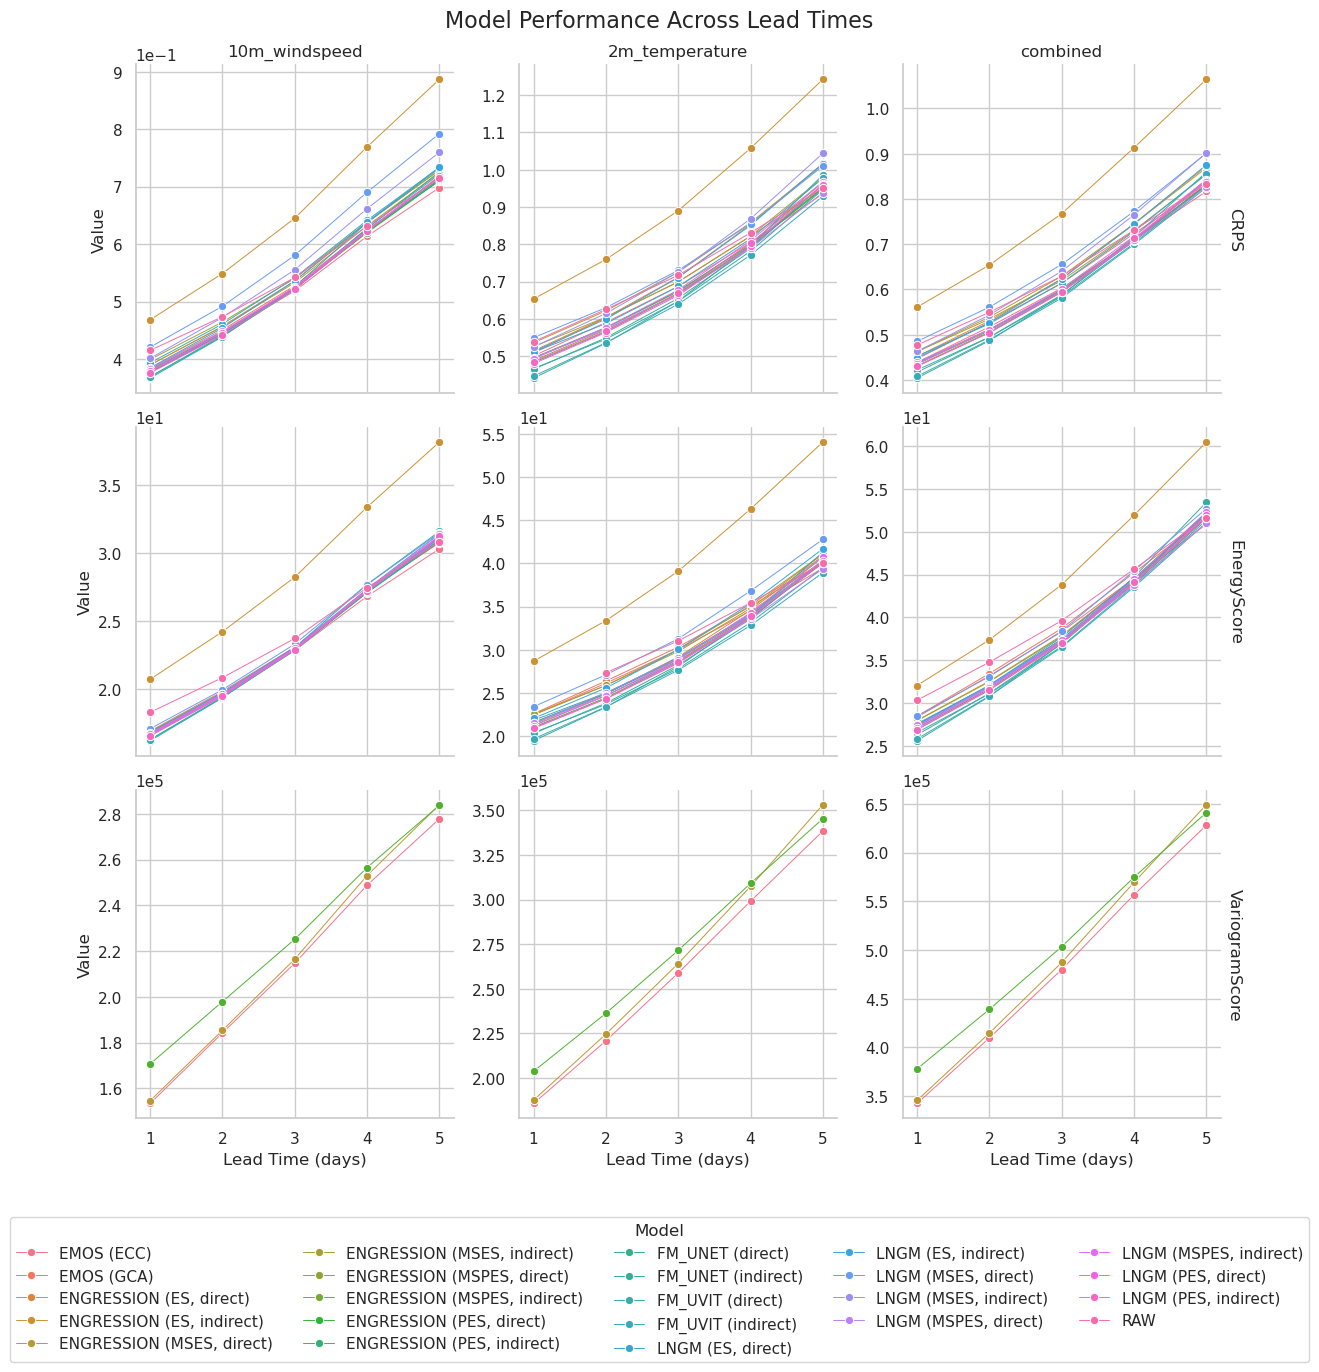

In [7]:
# Set seaborn style
sns.set_theme(style="whitegrid")
sns.set_palette("husl")  # Use tab10 colormap

# Convert to pandas for seaborn FacetGrid (works better with pandas)
df_pandas = df_plot.to_pandas()

# Get unique scores and variables to determine grid layout
n_scores = df_pandas["score"].nunique()
n_variables = df_pandas["variable"].nunique()

# Create FacetGrid with score as rows and variable as columns
g = sns.FacetGrid(
    df_pandas,
    col="variable",
    row="score",
    height=4,
    aspect=1,
    sharex=True,
    sharey=False,
    margin_titles=True,
)

# Plot lines for each model+method
g.map_dataframe(
    sns.lineplot,
    x="days",
    y="value",
    hue="model_method",
    style="model_method",
    marker="o",
    linewidth=0.7,
    dashes=False,
)

# Format y-axes with scientific notation for large numbers
for ax in g.axes.flat:
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

# Add legend below the plot with multiple columns
handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(
    handles, labels, title="Model", bbox_to_anchor=(0.5, -0.02), loc="upper center", ncol=5
)

# Set labels
g.set_axis_labels("Lead Time (days)", "Value")
g.set_titles(col_template="{col_name}", row_template="{row_name}")

plt.subplots_adjust(top=0.95)
g.figure.suptitle("Model Performance Across Lead Times", fontsize=16)
plt.tight_layout()
plt.show()

## Normalize

In [ ]:
df_plot = (
    df_plot.join(
        # Get the RAW values for each combination
        df_plot.filter(pl.col("model_method") == "RAW")
        .select(["timedelta", "score", "variable", "value"])
        .rename({"value": "raw_value"}),
        on=["timedelta", "score", "variable"],
        how="left",
    )
    .with_columns(
        # Calculate normalized value
        ((pl.col("value") - pl.col("raw_value")) / pl.col("raw_value")).alias("normalized_value")
    )
    .drop("raw_value")
)  # Remove the temporary raw_value column

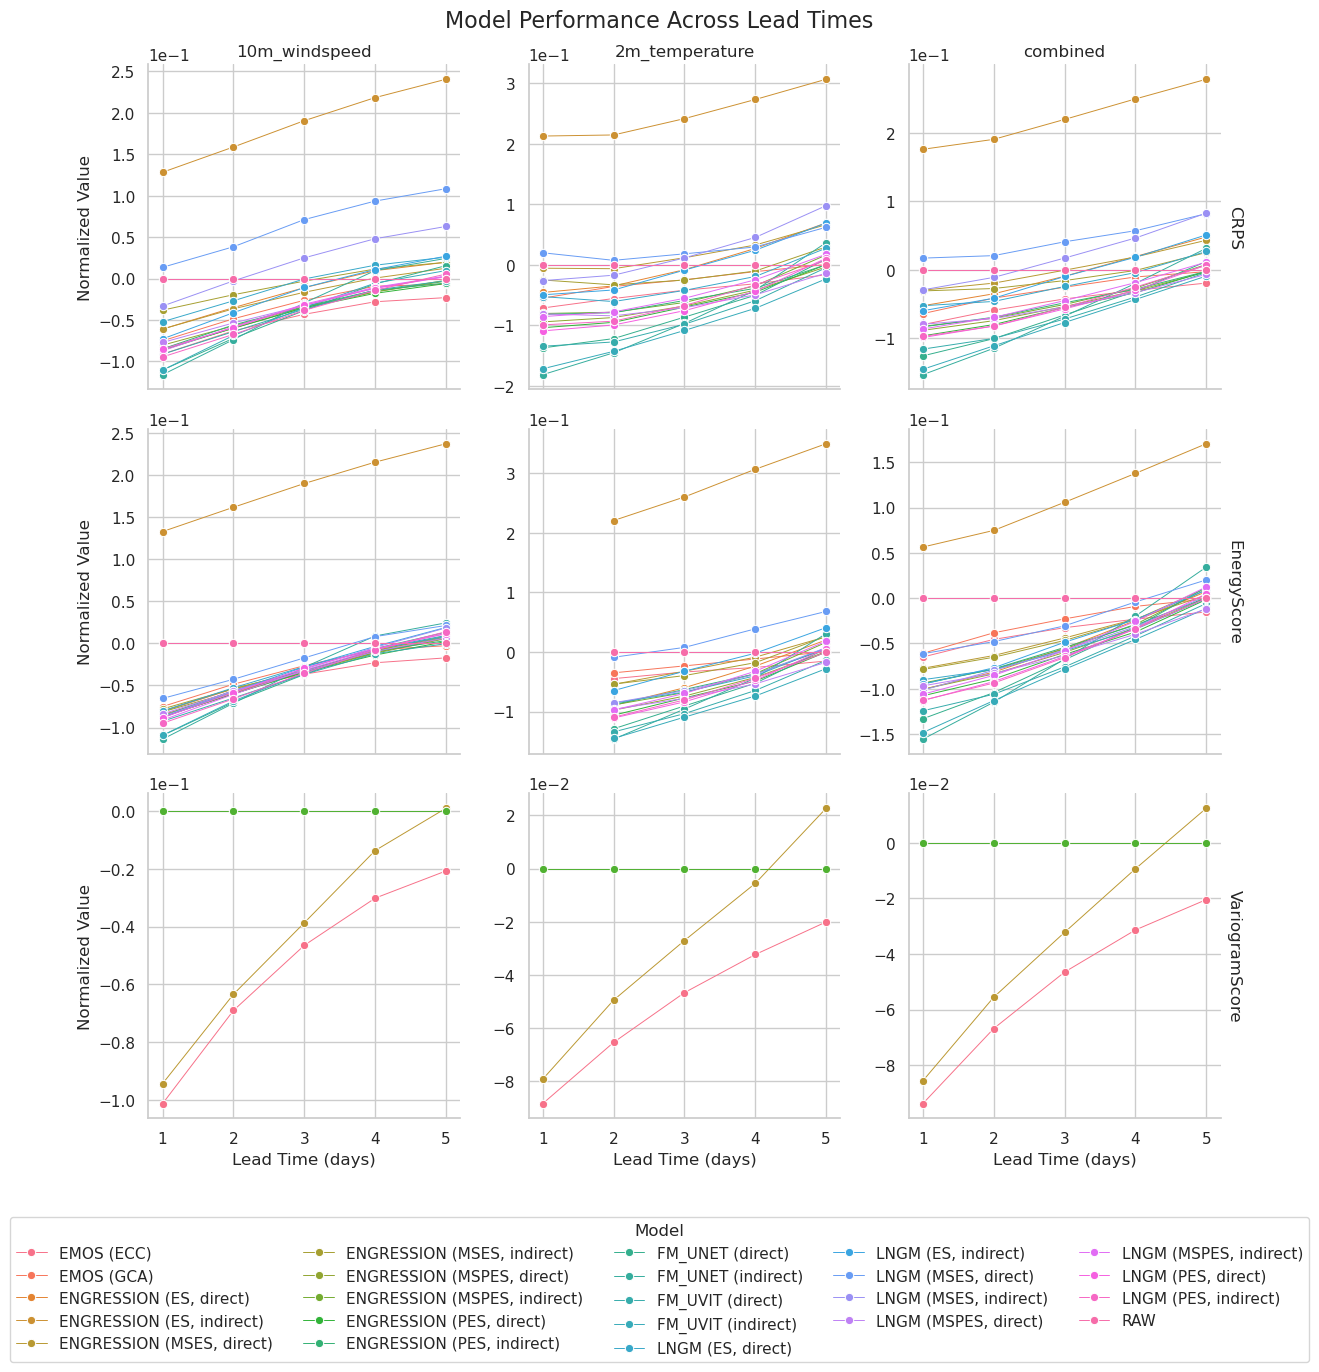

In [54]:
# Convert to pandas for seaborn FacetGrid (works better with pandas)
df_pandas = df_plot.to_pandas()

# Get unique scores and variables to determine grid layout
n_scores = df_pandas["score"].nunique()
n_variables = df_pandas["variable"].nunique()

# Create FacetGrid with score as rows and variable as columns
g = sns.FacetGrid(
    df_pandas,
    col="variable",
    row="score",
    height=4,
    aspect=1,
    sharex=True,
    sharey=False,
    margin_titles=True,
)

# Plot lines for each model+method
g.map_dataframe(
    sns.lineplot,
    x="days",
    y="normalized_value",
    hue="model_method",
    style="model_method",
    marker="o",
    linewidth=0.7,
    dashes=False,
)

# Format y-axes with scientific notation for large numbers
for ax in g.axes.flat:
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

# Add legend below the plot with multiple columns
handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(
    handles, labels, title="Model", bbox_to_anchor=(0.5, -0.02), loc="upper center", ncol=5
)

# Set labels
g.set_axis_labels("Lead Time (days)", "Normalized Value")
g.set_titles(col_template="{col_name}", row_template="{row_name}")

plt.subplots_adjust(top=0.95)
g.figure.suptitle("Model Performance Across Lead Times", fontsize=16)
plt.tight_layout()
plt.show()

## Plot each model class separately
- Use different markers for different Loss functions
- Use different linestyle for direct and indirect
- always keep RAW in every plot

In [41]:
model_typess = [
    ["EMOS", "DRN", "RAW"],
    ["LNGM", "RAW"],
    ["ENGRESSION", "RAW"],
    ["FM_UNET", "FM_UVIT", "RAW"],
]
# Color ranges for each model type
color_ranges = {
    "EMOS": sns.cubehelix_palette(start=0, rot=0.5, dark=0.25, light=0.75, n_colors=2),
    "DRN": sns.cubehelix_palette(start=0.5, rot=0.5, dark=0.25, light=0.75, n_colors=2),
    "LNGM": sns.cubehelix_palette(start=1, rot=0.5, dark=0.25, light=0.75, n_colors=8),
    "ENGRESSION": sns.cubehelix_palette(start=1.5, rot=0.5, dark=0.25, light=0.75, n_colors=8),
    "FM_UNET": sns.cubehelix_palette(start=2.0, rot=0.5, dark=0.25, light=0.75, n_colors=2),
    "FM_UVIT": sns.cubehelix_palette(start=2.5, rot=0.5, dark=0.25, light=0.75, n_colors=2),
    "RAW": "blue",
}

color_mapping = {
    "RAW": color_ranges["RAW"],
    "EMOS (ECC)": color_ranges["EMOS"][0],
    "EMOS (GCA)": color_ranges["EMOS"][1],
    "LNGM (ES, direct)": color_ranges["LNGM"][0],
    "LNGM (ES, indirect)": color_ranges["LNGM"][1],
    "LNGM (PES, direct)": color_ranges["LNGM"][2],
    "LNGM (PES, indirect)": color_ranges["LNGM"][3],
    "LNGM (MSES, direct)": color_ranges["LNGM"][4],
    "LNGM (MSES, indirect)": color_ranges["LNGM"][5],
    "LNGM (MSPES, direct)": color_ranges["LNGM"][6],
    "LNGM (MSPES, indirect)": color_ranges["LNGM"][7],
    "ENGRESSION (ES, direct)": color_ranges["ENGRESSION"][0],
    "ENGRESSION (ES, indirect)": color_ranges["ENGRESSION"][1],
    "ENGRESSION (PES, direct)": color_ranges["ENGRESSION"][2],
    "ENGRESSION (PES, indirect)": color_ranges["ENGRESSION"][3],
    "ENGRESSION (MSES, direct)": color_ranges["ENGRESSION"][4],
    "ENGRESSION (MSES, indirect)": color_ranges["ENGRESSION"][5],
    "ENGRESSION (MSPES, direct)": color_ranges["ENGRESSION"][6],
    "ENGRESSION (MSPES, indirect)": color_ranges["ENGRESSION"][7],
    "FM_UNET (direct)": color_ranges["FM_UNET"][0],
    "FM_UNET (indirect)": color_ranges["FM_UNET"][1],
    "FM_UVIT (direct)": color_ranges["FM_UVIT"][0],
    "FM_UVIT (indirect)": color_ranges["FM_UVIT"][1],
}

In [42]:
model_types = model_typess[1]

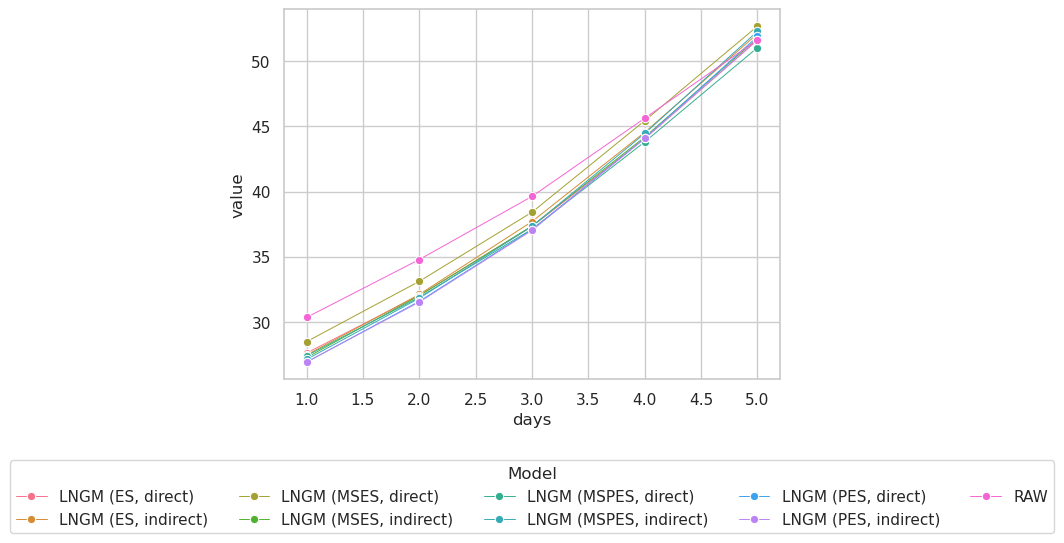

In [ ]:
df_filtered = df_plot.filter(
    pl.col("model_name").is_in(model_types) & pl.col("metric_name").eq("EnergyScore_combined")
)
# Plot here
fig = sns.lineplot(
    data=df_filtered,
    x="days",
    y="value",
    hue="model_method",
    style="model_method",
    marker="o",
    linewidth=0.7,
    dashes=False,
)

handles, labels = fig.get_legend_handles_labels()
fig.legend(handles, labels, title="Model", bbox_to_anchor=(0.5, -0.2), loc="upper center", ncol=5)